# Affective subspace interpretation

**Hypothesis being investigated.** The residual stream does *not* contain 8 discrete emotion buttons.
Instead there is a low-dimensional continuous affective subspace, and the 8 Plutchik labels
(`joy, trust, fear, surprise, sadness, disgust, anger, anticipation`) are human-applied
*prototype regions* inside that space.

Earlier analysis (see `continuous_affect_hypothesis.ipynb`) showed:

* 8 emotion centroids live near a ~3D subspace (participation ratio 3.68, top-3 EVR 0.81).
* Unsupervised k-means at k=8 fails to recover the labels (ARI ≈ 0.15).
* Hand-coded 2-axis VAD only recovers 64% of the 8-class accuracy — the space is richer than V-A but lower-dimensional than 8 labels.

**What this notebook adds.** It asks *what those continuous axes are about*. Specifically:

1. Source-center the activations so source-text semantics are mostly removed.
2. Compute 8 emotion centroids, SVD them, take PC1..PC4.
3. Tabulate per-emotion scores on each PC and show extreme rewrites along each PC.
4. Use OpenAI as a judge to score a stratified sample of rewrites on continuous affective
   attributes (valence, arousal, dominance, intensity, threat, warmth, certainty, agency).
5. Correlate judge scores with PC projections; also try to linearly predict the judge
   scores directly from the residual stream.
6. Compare the previously-found global intensity vector against the PCs and attributes.
7. Visualize the 8 emotions as regions of a 2D affect map.
8. Repeat the core SVD on layers 10 and 16 for robustness.

All OpenAI calls are cached to disk and resume on re-run. Set the API key in `OPENAI_API_KEY`.

## 0. Setup

Memory note: the full activation tensor is `(22782, 8, 3, 6, 4096) float32 ≈ 54 GB`.
We always work via `np.memmap` and a per-layer slice, and we subsample sources to keep
in-RAM arrays well under 4 GB per copy.

In [1]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import pathlib
import time
from dataclasses import dataclass
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

ROOT = pathlib.Path('/home/maplesugano/proj/EmotionEngine_v2')
ACT_DIR = ROOT / 'activation' / 'emotion_rewrites'
ACT_PATH = ACT_DIR / 'emotion_intensity_residual_stream.npy'
INFO_PATH = ACT_DIR / 'emotion_intensity_residual_stream_info.json'
REWRITE_JSONL = ROOT / 'dataset' / 'emotion_rewrites' / 'emotion_rewrites.jsonl'
OUT_DIR = ROOT / 'analysis' / 'emotion_intensity' / 'affective_subspace'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUT_DIR / 'judge_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
rng = np.random.default_rng(SEED)

LAYER_PRIMARY = 13
LAYERS_AUX = [10, 16]
K_PCS = 4
MAX_SOURCES = 2500          # RAM cap on the projection table
JUDGE_MODEL = 'gpt-4o-mini'
JUDGE_SAMPLE_PER_CELL = 8   # 8 emotions x 3 intensities x 8 = 192 first pass
JUDGE_MAX_TOTAL = 2000      # safety cap

sns.set_context('notebook')
sns.set_style('whitegrid')
print('OUT_DIR =', OUT_DIR)

OUT_DIR = /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/affective_subspace


In [2]:
with open(INFO_PATH) as f:
    INFO = json.load(f)

LAYERS = INFO['layer_indices']
EMOTIONS = INFO['emotion_order']
INTENSITIES = INFO['intensity_order']
SOURCE_IDS = INFO['source_ids']
N = len(SOURCE_IDS)
N_EMO = len(EMOTIONS)
N_INT = len(INTENSITIES)
N_LAY = len(LAYERS)
LAYER_TO_IDX = {l: i for i, l in enumerate(LAYERS)}

# Memmap; never materialize the full tensor.
SHAPE = tuple(INFO['shape'])
DTYPE = INFO.get('dtype', 'float32')
ACT = np.memmap(str(ACT_PATH), dtype=DTYPE, mode='r', shape=SHAPE)
D = ACT.shape[-1]
print('ACT shape =', ACT.shape, 'dtype =', DTYPE)
print('layers =', LAYERS, '| primary =', LAYER_PRIMARY)
print('emotions =', EMOTIONS)
print('intensities =', INTENSITIES)
print('N sources =', N, '| D =', D)

# Stable source subsample (RAM cap).
if N > MAX_SOURCES:
    SRC_SUBSAMPLE = np.sort(rng.choice(N, size=MAX_SOURCES, replace=False))
else:
    SRC_SUBSAMPLE = np.arange(N)
N_SUB = len(SRC_SUBSAMPLE)
SRC_ID_SUB = [SOURCE_IDS[i] for i in SRC_SUBSAMPLE]
print(f'Working on {N_SUB} of {N} sources.')

ACT shape = (22782, 8, 3, 6, 4096) dtype = float32
layers = [8, 10, 13, 16, 19, 22] | primary = 13
emotions = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
intensities = ['low', 'medium', 'high']
N sources = 22782 | D = 4096
Working on 2500 of 22782 sources.


In [3]:
# Load the rewrite texts and build a (source_id, emotion, intensity) -> text registry.
REGISTRY: dict[tuple[str, str, str], str] = {}
BASE_TEXT: dict[str, str] = {}
with open(REWRITE_JSONL) as f:
    for line in f:
        rec = json.loads(line)
        sid = rec['source_id']
        lvl = rec['intensity_level']
        BASE_TEXT.setdefault(sid, rec.get('base_text', ''))
        for emo in EMOTIONS:
            key = (sid, emo, lvl)
            REGISTRY[key] = rec[f'{emo}_rewrite']
print('registry size =', len(REGISTRY), '(expected', N * N_EMO * N_INT, ')')

registry size = 546768 (expected 546768 )


## 1. Source-centered activations and emotion centroids

For each source `s`, intensity `i`, emotion `e` we have an activation `X[s, e, i]` at the chosen layer.
We subtract the per-source-per-intensity mean across the 8 emotions:

$$ R[s, e, i] = X[s, e, i] - \frac{1}{|E|} \sum_{e'} X[s, e', i] $$

This removes most of the topic/base-text content, leaving the emotion-specific deviation.
The emotion centroid for emotion `e` is then $C_e = \text{mean}_{s,i}\, R[s, e, i]$, a $D$-dim vector.

In [4]:
def load_layer_sub(layer: int) -> np.ndarray:
    """Return float32 (N_SUB, N_EMO, N_INT, D) for one layer, on the source subsample."""
    li = LAYER_TO_IDX[layer]
    # ACT shape: (N, N_EMO, N_INT, N_LAY, D). Slice the layer first to avoid loading more.
    sl = np.asarray(ACT[SRC_SUBSAMPLE, :, :, li, :], dtype=np.float32)
    return sl  # ~1.0 GB for N_SUB=2500

def source_center(X: np.ndarray) -> np.ndarray:
    """R[s,e,i] = X[s,e,i] - mean_{e'} X[s,e',i]. Same shape as X."""
    # mean over emotion axis (axis=1)
    mu = X.mean(axis=1, keepdims=True)
    return X - mu

def emotion_centroids(R: np.ndarray) -> np.ndarray:
    """C: (N_EMO, D) = mean over (s, i) of R."""
    return R.mean(axis=(0, 2))

X_L = load_layer_sub(LAYER_PRIMARY)
R_L = source_center(X_L)
C_L = emotion_centroids(R_L)
print('X_L:', X_L.shape, '| R_L:', R_L.shape, '| C_L:', C_L.shape)
print(f'mem MB: X={X_L.nbytes/1e6:.0f}  R={R_L.nbytes/1e6:.0f}  C={C_L.nbytes/1e6:.1f}')

X_L: (2500, 8, 3, 4096) | R_L: (2500, 8, 3, 4096) | C_L: (8, 4096)
mem MB: X=983  R=983  C=0.1


## 2. PCA of emotion centroids

SVD of the 8 centroid vectors gives us a basis for the affective subspace.
Because we already source-centered, we also subtract the *grand* centroid before SVD
so PCs describe deviations between emotions, not a shared shift.

In [5]:
def svd_centroids(C: np.ndarray, k: int = K_PCS) -> dict:
    mu = C.mean(axis=0, keepdims=True)
    Cc = C - mu
    U, S, Vt = np.linalg.svd(Cc, full_matrices=False)
    evr = (S ** 2) / (S ** 2).sum()
    PCs = Vt[:k]                       # (k, D)
    scores = Cc @ PCs.T                # (N_EMO, k)  per-emotion score on each PC
    return {
        'mu': mu.squeeze(0),
        'PCs': PCs,
        'S': S,
        'evr': evr,
        'scores': scores,
    }

pca = svd_centroids(C_L, k=K_PCS)
print('singular values:', pca['S'])
print('EVR            :', np.round(pca['evr'], 3))
print('cum EVR        :', np.round(np.cumsum(pca['evr']), 3))

score_df = pd.DataFrame(pca['scores'], index=EMOTIONS,
                        columns=[f'PC{i+1}' for i in range(K_PCS)]).round(3)
score_df['||centroid||'] = np.linalg.norm(C_L - pca['mu'], axis=1).round(2)
score_df.to_csv(OUT_DIR / 'pca_emotion_scores.csv')
score_df

singular values: [1.9993472e+00 1.5174447e+00 1.1527946e+00 8.9263237e-01 7.4510169e-01
 5.7139605e-01 3.7212783e-01 5.0098276e-08]
EVR            : [0.423 0.244 0.141 0.084 0.059 0.035 0.015 0.   ]
cum EVR        : [0.423 0.667 0.808 0.892 0.951 0.985 1.    1.   ]


,PC1,PC2,PC3,PC4,||centroid||
joy,-0.943,0.340,-0.323,-0.473,1.19
trust,-1.003,-0.249,-0.371,0.565,1.25
fear,0.359,-0.653,0.558,0.186,1.01
surprise,0.167,1.228,0.432,0.236,1.33
sadness,0.469,-0.145,0.088,-0.337,0.82
disgust,0.761,-0.073,-0.428,0.051,0.92
anger,0.846,-0.047,-0.423,-0.010,1.04
anticipation,-0.657,-0.401,0.468,-0.217,1.03


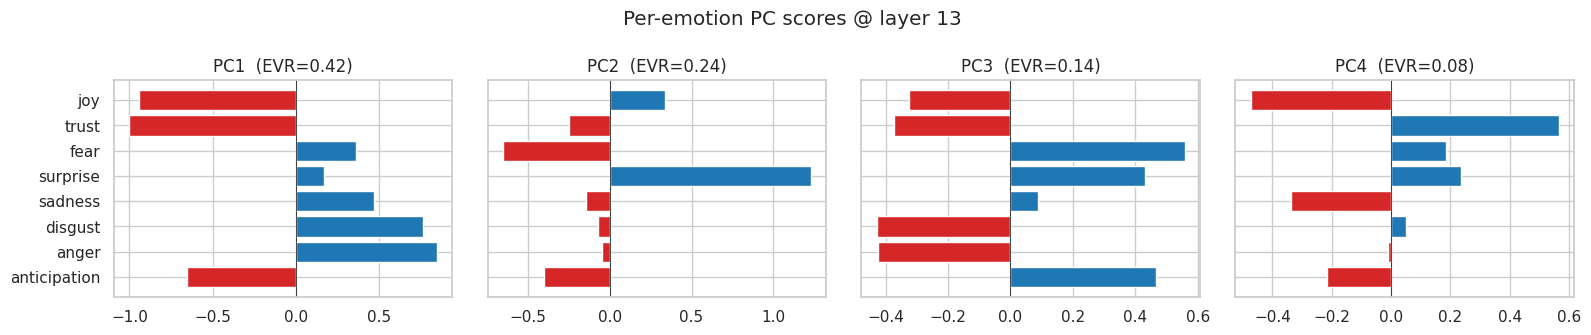

In [6]:
# Quick visual: per-emotion bar chart for each PC. Helps eyeball which emotions
# sit on which side of each axis.
fig, axes = plt.subplots(1, K_PCS, figsize=(4 * K_PCS, 3.4), sharey=True)
order = EMOTIONS
for k in range(K_PCS):
    ax = axes[k]
    vals = pca['scores'][:, k]
    colors = ['#1f77b4' if v >= 0 else '#d62728' for v in vals]
    ax.barh(order, vals, color=colors)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'PC{k+1}  (EVR={pca["evr"][k]:.2f})')
axes[0].invert_yaxis()
fig.suptitle(f'Per-emotion PC scores @ layer {LAYER_PRIMARY}')
fig.tight_layout()
fig.savefig(OUT_DIR / 'pca_emotion_scores.png', dpi=140)
plt.show()

## 3. Project all rewrites onto the PCs

We project the source-centered rewrite activations onto PC1..PC4.
This gives a tidy long-form `(source_id, emotion, intensity, pc1, pc2, pc3, pc4)` table
we can join with judge scores later.

In [7]:
def project_rewrites(R: np.ndarray, pca: dict, source_ids: list[str]) -> pd.DataFrame:
    """R: (N_SUB, N_EMO, N_INT, D) source-centered. Returns long df."""
    Rc = R - pca['mu']                           # broadcast (D,)
    proj = Rc.reshape(-1, R.shape[-1]) @ pca['PCs'].T   # (N_SUB*E*I, k)
    n_sub, n_e, n_i, _ = R.shape
    s_idx = np.repeat(np.arange(n_sub), n_e * n_i)
    e_idx = np.tile(np.repeat(np.arange(n_e), n_i), n_sub)
    i_idx = np.tile(np.arange(n_i), n_sub * n_e)
    df = pd.DataFrame({
        'source_id': [source_ids[i] for i in s_idx],
        'emotion':   [EMOTIONS[i] for i in e_idx],
        'intensity': [INTENSITIES[i] for i in i_idx],
    })
    for k in range(proj.shape[1]):
        df[f'PC{k+1}'] = proj[:, k]
    return df

PROJ = project_rewrites(R_L, pca, SRC_ID_SUB)
PROJ.to_parquet(OUT_DIR / 'rewrite_pc_projections.parquet')
print(PROJ.shape)
PROJ.head()

(60000, 7)


,source_id,emotion,intensity,PC1,PC2,PC3,PC4
0,dd_test_193_0,joy,low,-0.484367,0.124848,0.609353,-0.353504
1,dd_test_193_0,joy,medium,-0.069439,0.532555,0.163503,-0.266621
2,dd_test_193_0,joy,high,-0.088938,1.031604,0.895051,0.037107
3,dd_test_193_0,trust,low,-0.494699,-0.117616,-0.873360,-0.012305
4,dd_test_193_0,trust,medium,-0.881615,-0.403743,-0.279200,0.237129


In [8]:
# Per-emotion mean and 25/75 quantiles on each PC: do the rewrite-level projections
# reproduce the centroid-level ordering? (Sanity check for axis stability.)
agg = PROJ.groupby('emotion')[[f'PC{k+1}' for k in range(K_PCS)]].agg(['mean', 'std'])
agg = agg.reindex(EMOTIONS)
agg.round(3)

PC1           PC2           PC3           PC4       
               mean    std   mean    std   mean    std   mean    std
emotion                                                             
joy          -0.943  0.460  0.340  0.639 -0.323  0.361 -0.473  0.397
trust        -1.003  0.464 -0.249  0.490 -0.371  0.341  0.565  0.466
fear          0.359  0.424 -0.653  0.541  0.558  0.404  0.186  0.392
surprise      0.167  0.406  1.228  0.619  0.432  0.312  0.236  0.380
sadness       0.469  0.401 -0.145  0.510  0.088  0.292 -0.337  0.373
disgust       0.761  0.395 -0.073  0.495 -0.428  0.356  0.051  0.376
anger         0.846  0.408 -0.047  0.519 -0.423  0.347 -0.010  0.367
anticipation -0.657  0.510 -0.401  0.521  0.468  0.421 -0.217  0.369

## 4. Extreme rewrites per PC (axis interpretation)

For each PC, we print the top-N rewrites on the positive side and on the negative side.
Reading them by hand is the most direct way to assign a plain-English label to each axis
before we even involve the judge.

In [9]:
def extreme_examples(df: pd.DataFrame, pc: str, n: int = 6) -> pd.DataFrame:
    pos = df.nlargest(n, pc).copy(); pos['side'] = '+'
    neg = df.nsmallest(n, pc).copy(); neg['side'] = '-'
    both = pd.concat([pos, neg], ignore_index=True)
    both['text'] = [REGISTRY.get((s, e, i), '<missing>')
                    for s, e, i in zip(both['source_id'], both['emotion'], both['intensity'])]
    return both[['side', pc, 'emotion', 'intensity', 'source_id', 'text']]

EXTREMES: dict[str, pd.DataFrame] = {}
for k in range(K_PCS):
    pc = f'PC{k+1}'
    EXTREMES[pc] = extreme_examples(PROJ, pc, n=6)
    EXTREMES[pc].to_csv(OUT_DIR / f'extremes_{pc}.csv', index=False)
    print(f'\n=== {pc}  (EVR={pca["evr"][k]:.2f}) ===')
    for _, row in EXTREMES[pc].iterrows():
        snippet = row['text'][:160].replace('\n', ' ')
        print(f"  {row['side']}{row[pc]:+.2f}  [{row['emotion']:<13}|{row['intensity']:<6}]  {snippet}")


=== PC1  (EVR=0.42) ===
  ++2.50  [disgust      |high  ]  Everyone bailed for their own plans, leaving me stuck here alone. I shouldn’t have to be the one reaching out for company.
  ++2.21  [anger        |medium]  My water heater broke? Seriously? This is so frustrating—why does stuff always break when I don’t need it to?
  ++2.19  [disgust      |low   ]  I wasn’t thrilled to find the post office closed when I arrived—it feels like they don’t care about people’s time.
  ++2.09  [anger        |high  ]  My water heater broke? This is ridiculous! Why does something important always fail at the worst time?
  ++2.07  [anger        |medium]  I was about to go on maternity leave, and they threw a baby shower without even telling me first? That feels disrespectful.
  ++2.07  [anger        |high  ]  These storms happen way too often in fall and spring, so I had no choice but to create a storm emergency kit for the basement. It's infuriating to have to keep 
  --2.72  [joy          |high  ]  I

## 5. Stratified sample for LLM-as-a-judge

We sample uniformly across `(emotion, intensity)` cells so the judge sees a balanced
view of the space. We also pick a few items at the *extreme ends* of each PC, so the
judge has something to anchor each axis against.

In [10]:
def build_judge_sample(
    proj: pd.DataFrame,
    per_cell: int = JUDGE_SAMPLE_PER_CELL,
    extras_per_pc: int = 4,
    seed: int = SEED,
) -> pd.DataFrame:
    rng_local = np.random.default_rng(seed)
    pieces = []
    for emo in EMOTIONS:
        for lvl in INTENSITIES:
            sub = proj[(proj.emotion == emo) & (proj.intensity == lvl)]
            take = sub.sample(n=min(per_cell, len(sub)), random_state=int(rng_local.integers(1 << 31)))
            pieces.append(take)
    for k in range(K_PCS):
        pc = f'PC{k+1}'
        pieces.append(proj.nlargest(extras_per_pc, pc))
        pieces.append(proj.nsmallest(extras_per_pc, pc))
    out = pd.concat(pieces, ignore_index=True).drop_duplicates(
        subset=['source_id', 'emotion', 'intensity']
    )
    out = out.head(JUDGE_MAX_TOTAL).reset_index(drop=True)
    out['sample_id'] = out.apply(
        lambda r: f"{r['source_id']}|{r['emotion']}|{r['intensity']}", axis=1
    )
    out['text'] = [REGISTRY[(s, e, i)] for s, e, i in zip(out['source_id'], out['emotion'], out['intensity'])]
    return out

JUDGE_SAMPLE = build_judge_sample(PROJ)
print('judge sample size =', len(JUDGE_SAMPLE))
print(JUDGE_SAMPLE.groupby(['emotion', 'intensity']).size().unstack(fill_value=0))
JUDGE_SAMPLE.to_parquet(OUT_DIR / 'judge_sample.parquet')

judge sample size = 224
intensity     high  low  medium
emotion                        
anger            9    8      10
anticipation     8    9       9
disgust         11    9       9
fear            13    8       9
joy             12    8       9
sadness          8    8       8
surprise        11    8       9
trust           12    9      10


## 6. OpenAI judge — cached, resumable

The judge produces 8 continuous affective attributes per text, returned as strict JSON.
Each sample is cached in its own file under `judge_cache/`, keyed by a hash of
`(model, prompt_version, text)`. Re-running the cell is idempotent.

Set the API key first:

```bash
export OPENAI_API_KEY=sk-...
```

To do a *dry run* without hitting the API, set `DRY_RUN = True` below — it will fill
the cache with zeros so the rest of the notebook still runs end-to-end.

In [11]:
PROMPT_VERSION = 'v1'
DRY_RUN = False  # set True to fill the cache with zeros (no API calls)

JUDGE_ATTRS = [
    'valence', 'arousal', 'dominance', 'emotional_intensity',
    'threat', 'social_warmth', 'certainty', 'agency',
]

ATTR_RANGES = {
    'valence':             (-1.0, 1.0),
    'arousal':             (0.0, 1.0),
    'dominance':           (-1.0, 1.0),
    'emotional_intensity': (0.0, 1.0),
    'threat':              (0.0, 1.0),
    'social_warmth':       (-1.0, 1.0),
    'certainty':           (-1.0, 1.0),
    'agency':              (-1.0, 1.0),
}

JUDGE_SYSTEM = (
    'You are an expert affective-computing annotator. Given one short piece of text, '
    'rate the *affective state of the speaker as expressed by the text*, not your '
    'opinion of the text. Output strict JSON conforming to the schema. Use the full '
    'range and be decisive; do not default to zero.'
)

JUDGE_USER_TMPL = (
    'Rate the speaker on these continuous affective attributes. Each is a single number.\n\n'
    'Scales:\n'
    '- valence             in [-1, 1]   negative <-> positive feeling\n'
    '- arousal             in [ 0, 1]   calm    <-> highly aroused / energized / tense\n'
    '- dominance           in [-1, 1]   powerless / submissive <-> in-control / dominant\n'
    '- emotional_intensity in [ 0, 1]   flat <-> intense emotion of any kind\n'
    '- threat              in [ 0, 1]   safe <-> perceiving danger or threat\n'
    '- social_warmth       in [-1, 1]   cold/hostile <-> warm/affiliative\n'
    '- certainty           in [-1, 1]   confused/uncertain <-> confident/certain\n'
    '- agency              in [-1, 1]   passive/acted-upon <-> active/initiating\n\n'
    'TEXT:\n"""\n{text}\n"""\n'
)

JUDGE_SCHEMA = {
    'name': 'affect_scores',
    'strict': True,
    'schema': {
        'type': 'object',
        'additionalProperties': False,
        'properties': {k: {'type': 'number'} for k in JUDGE_ATTRS},
        'required': JUDGE_ATTRS,
    },
}

def _cache_key(text: str) -> str:
    h = hashlib.sha1()
    h.update(JUDGE_MODEL.encode()); h.update(b'|')
    h.update(PROMPT_VERSION.encode()); h.update(b'|')
    h.update(text.encode('utf-8'))
    return h.hexdigest()[:24]

def _cache_path(text: str) -> pathlib.Path:
    return CACHE_DIR / f'{_cache_key(text)}.json'

def _clip(d: dict) -> dict:
    out = {}
    for k, (lo, hi) in ATTR_RANGES.items():
        v = float(d.get(k, 0.0))
        out[k] = float(np.clip(v, lo, hi))
    return out

_client = None
def _get_client():
    global _client
    if _client is None:
        from openai import OpenAI
        if not os.environ.get('OPENAI_API_KEY'):
            raise RuntimeError('OPENAI_API_KEY is not set. Export it or set DRY_RUN=True.')
        _client = OpenAI()
    return _client

def judge_one(text: str) -> dict:
    p = _cache_path(text)
    if p.exists():
        with open(p) as f:
            return json.load(f)
    if DRY_RUN:
        scores = {k: 0.0 for k in JUDGE_ATTRS}
        with open(p, 'w') as f:
            json.dump(scores, f)
        return scores
    client = _get_client()
    resp = client.chat.completions.create(
        model=JUDGE_MODEL,
        temperature=0.0,
        messages=[
            {'role': 'system', 'content': JUDGE_SYSTEM},
            {'role': 'user',   'content': JUDGE_USER_TMPL.format(text=text)},
        ],
        response_format={'type': 'json_schema', 'json_schema': JUDGE_SCHEMA},
    )
    raw = resp.choices[0].message.content
    scores = _clip(json.loads(raw))
    with open(p, 'w') as f:
        json.dump(scores, f)
    return scores

def judge_many(texts: list[str], progress_every: int = 25) -> list[dict]:
    out = []
    n = len(texts)
    t0 = time.time()
    for i, t in enumerate(texts):
        out.append(judge_one(t))
        if (i + 1) % progress_every == 0 or i == n - 1:
            dt = time.time() - t0
            print(f'  judged {i+1}/{n}  ({dt:.1f}s, {(i+1)/max(dt,1e-9):.2f}/s)')
    return out

print('judge configured. model =', JUDGE_MODEL, '| DRY_RUN =', DRY_RUN)
print('cache dir =', CACHE_DIR)

judge configured. model = gpt-4o-mini | DRY_RUN = False
cache dir = /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/affective_subspace/judge_cache


In [12]:
# Run the judge over the sample. Resumable: already-cached items are free.
scores_list = judge_many(JUDGE_SAMPLE['text'].tolist())
JUDGE_SCORES = pd.DataFrame(scores_list)
JUDGE_DF = pd.concat([JUDGE_SAMPLE.reset_index(drop=True), JUDGE_SCORES], axis=1)
JUDGE_DF.to_parquet(OUT_DIR / 'judge_scores.parquet')
print('rows:', len(JUDGE_DF))
JUDGE_DF[['emotion'] + JUDGE_ATTRS].groupby('emotion').mean().round(2).reindex(EMOTIONS)

  judged 25/224  (38.3s, 0.65/s)
  judged 50/224  (70.5s, 0.71/s)
  judged 75/224  (102.9s, 0.73/s)
  judged 100/224  (141.3s, 0.71/s)
  judged 125/224  (172.5s, 0.72/s)
  judged 150/224  (206.6s, 0.73/s)
  judged 175/224  (240.0s, 0.73/s)
  judged 200/224  (275.4s, 0.73/s)
  judged 224/224  (306.1s, 0.73/s)
rows: 224


,valence,arousal,dominance,emotional_intensity,threat,social_warmth,certainty,agency
emotion,,,,,,,,
joy,0.68,0.46,0.35,0.50,0.05,0.61,0.61,0.44
trust,0.61,0.36,0.38,0.47,0.08,0.62,0.61,0.46
fear,-0.18,0.53,-0.21,0.55,0.59,0.14,-0.15,-0.18
surprise,0.34,0.53,0.12,0.52,0.10,0.45,0.32,0.16
sadness,-0.35,0.43,-0.32,0.52,0.29,0.10,-0.09,-0.31
disgust,-0.40,0.50,-0.23,0.57,0.28,-0.14,0.03,-0.20
anger,-0.40,0.59,-0.22,0.61,0.23,-0.17,-0.06,-0.20
anticipation,0.47,0.47,0.20,0.50,0.11,0.52,0.46,0.32


## 7. Correlate PC projections with judge attributes

If a PC tracks a specific affective attribute, we should see a strong (Spearman) correlation
between the rewrite's PC score and the judge's score for that attribute.

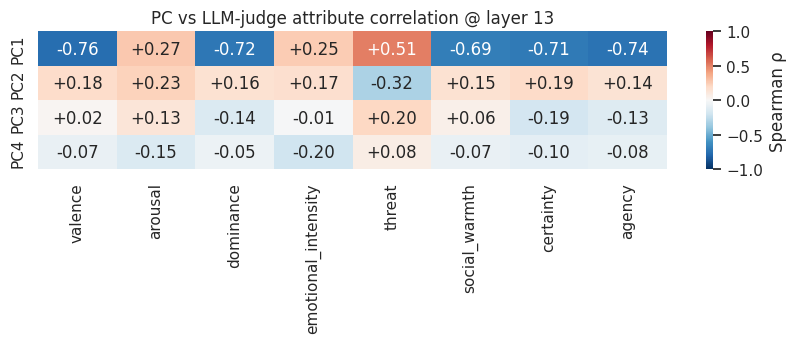

,valence,arousal,dominance,emotional_intensity,threat,social_warmth,certainty,agency
PC1,-0.76,0.27,-0.72,0.25,0.51,-0.69,-0.71,-0.74
PC2,0.18,0.23,0.16,0.17,-0.32,0.15,0.19,0.14
PC3,0.02,0.13,-0.14,-0.01,0.20,0.06,-0.19,-0.13
PC4,-0.07,-0.15,-0.05,-0.20,0.08,-0.07,-0.10,-0.08


In [13]:
def corr_pc_vs_attrs(df: pd.DataFrame, method: str = 'spearman') -> pd.DataFrame:
    pcs = [f'PC{k+1}' for k in range(K_PCS)]
    out = pd.DataFrame(index=pcs, columns=JUDGE_ATTRS, dtype=float)
    for pc in pcs:
        for attr in JUDGE_ATTRS:
            x = df[pc].to_numpy()
            y = df[attr].to_numpy()
            if np.std(y) < 1e-9:
                out.loc[pc, attr] = np.nan
                continue
            r = stats.spearmanr(x, y).statistic if method == 'spearman' else stats.pearsonr(x, y).statistic
            out.loc[pc, attr] = r
    return out

CORR = corr_pc_vs_attrs(JUDGE_DF, 'spearman')
CORR.to_csv(OUT_DIR / 'pc_vs_judge_corr.csv')

fig, ax = plt.subplots(figsize=(8.5, 3.6))
sns.heatmap(CORR.astype(float), annot=True, fmt='+.2f', center=0,
            cmap='RdBu_r', vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Spearman ρ'})
ax.set_title(f'PC vs LLM-judge attribute correlation @ layer {LAYER_PRIMARY}')
fig.tight_layout()
fig.savefig(OUT_DIR / 'pc_vs_judge_corr.png', dpi=140)
plt.show()
CORR.round(2)

In [14]:
# Best-matching attribute for each PC. Robust to all-NaN rows (e.g. dry-run).
best = []
for pc in CORR.index:
    row = CORR.loc[pc].astype(float)
    abs_row = row.abs()
    if abs_row.isna().all():
        best.append({'PC': pc, 'best_attr': None, 'rho': float('nan')})
        continue
    idx = abs_row.idxmax()
    best.append({'PC': pc, 'best_attr': idx, 'rho': float(row[idx])})
BEST_MATCH = pd.DataFrame(best)
BEST_MATCH.to_csv(OUT_DIR / 'pc_best_attr.csv', index=False)
BEST_MATCH

,PC,best_attr,rho
0,PC1,valence,-0.763396
1,PC2,threat,-0.319505
2,PC3,threat,0.204034
3,PC4,emotional_intensity,-0.200476


## 8. Linearly predict judge scores from activations

If the residual stream really encodes these continuous attributes, a *single linear probe*
should recover each judge score from the activation. We use the source-centered activations
of the same sample, with a group-KFold over `source_id` so we test cross-source generalization.

In [15]:
# Pull the activation for each judge sample. We already have R_L (source-centered) in memory.
SRC_POS = {sid: i for i, sid in enumerate(SRC_ID_SUB)}
EMO_POS = {e: i for i, e in enumerate(EMOTIONS)}
INT_POS = {l: i for i, l in enumerate(INTENSITIES)}

def activation_matrix(df: pd.DataFrame, R: np.ndarray) -> np.ndarray:
    rows = []
    for s, e, i in zip(df['source_id'], df['emotion'], df['intensity']):
        rows.append(R[SRC_POS[s], EMO_POS[e], INT_POS[i]])
    return np.asarray(rows, dtype=np.float32)

A_sample = activation_matrix(JUDGE_DF, R_L)
groups = JUDGE_DF['source_id'].to_numpy()
print('A_sample:', A_sample.shape)

def probe_attr(A: np.ndarray, y: np.ndarray, groups: np.ndarray, alphas=(1.0, 10.0, 100.0, 1000.0)) -> dict:
    if np.std(y) < 1e-9:
        return {'r2_cv': np.nan, 'pearson_cv': np.nan}
    n_groups = len(np.unique(groups))
    n_splits = min(3, n_groups)
    if n_splits < 2:
        return {'r2_cv': np.nan, 'pearson_cv': np.nan}
    gkf = GroupKFold(n_splits=n_splits)
    preds = np.zeros_like(y, dtype=float)
    for tr, te in gkf.split(A, y, groups):
        sc = StandardScaler(with_mean=False).fit(A[tr])
        model = RidgeCV(alphas=alphas).fit(sc.transform(A[tr]), y[tr])
        preds[te] = model.predict(sc.transform(A[te]))
    ss_res = float(np.sum((y - preds) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / max(ss_tot, 1e-12)
    pear = float(stats.pearsonr(preds, y).statistic)
    return {'r2_cv': r2, 'pearson_cv': pear}

probe_rows = []
for attr in JUDGE_ATTRS:
    y = JUDGE_DF[attr].to_numpy(dtype=float)
    out = probe_attr(A_sample, y, groups)
    probe_rows.append({'attr': attr, **out, 'y_std': float(np.std(y))})
PROBE = pd.DataFrame(probe_rows)
PROBE.to_csv(OUT_DIR / 'judge_probe_from_activation.csv', index=False)
PROBE.round(3)

A_sample: (224, 4096)


,attr,r2_cv,pearson_cv,y_std
0,valence,0.543,0.742,0.566
1,arousal,0.149,0.432,0.159
2,dominance,0.487,0.705,0.372
3,emotional_intensity,0.093,0.358,0.149
4,threat,0.379,0.620,0.242
5,social_warmth,0.422,0.659,0.428
6,certainty,0.417,0.658,0.442
7,agency,0.482,0.702,0.410


## 9. Global intensity vector vs. the affective subspace

We re-derive the global intensity direction (`mean over (s,e) of X[high] - X[low]`),
and compare it against PC1..PC4 and against the judge `emotional_intensity` attribute.

In [16]:
def intensity_vector(X: np.ndarray) -> np.ndarray:
    # X: (N_SUB, N_EMO, N_INT, D); we use raw X (not source-centered) for the intensity axis.
    hi = X[:, :, INT_POS['high'], :].mean(axis=(0, 1))
    lo = X[:, :, INT_POS['low'],  :].mean(axis=(0, 1))
    v = hi - lo
    return v / (np.linalg.norm(v) + 1e-12)

v_int = intensity_vector(X_L)
pc_norm = pca['PCs'] / (np.linalg.norm(pca['PCs'], axis=1, keepdims=True) + 1e-12)
cos_int_pc = pc_norm @ v_int
cos_int_table = pd.DataFrame({'PC': [f'PC{k+1}' for k in range(K_PCS)],
                              'cos_with_v_int': cos_int_pc.round(3)})
print('cos(v_int, PCk):')
print(cos_int_table.to_string(index=False))

# Project all judge-sample activations onto v_int and correlate with judge attrs.
proj_int = A_sample @ v_int
v_int_corr = {}
for attr in JUDGE_ATTRS:
    y = JUDGE_DF[attr].to_numpy(dtype=float)
    if np.std(y) < 1e-9:
        v_int_corr[attr] = np.nan
    else:
        v_int_corr[attr] = float(stats.spearmanr(proj_int, y).statistic)
V_INT_CORR = pd.Series(v_int_corr, name='spearman_rho').to_frame()
V_INT_CORR.to_csv(OUT_DIR / 'v_intensity_vs_judge.csv')
V_INT_CORR.round(2)

cos(v_int, PCk):
 PC  cos_with_v_int
PC1           0.344
PC2           0.105
PC3          -0.027
PC4          -0.233


,spearman_rho
valence,-0.34
arousal,0.49
dominance,-0.34
emotional_intensity,0.46
threat,0.27
social_warmth,-0.35
certainty,-0.30
agency,-0.32


## 10. 2D affect map

Scatter the rewrite projections on PC1/PC2 (and PC1/PC3) and overlay the 8 emotion centroids
as prototypes. The point is to see emotions as *regions* in a continuous space rather than
isolated points.

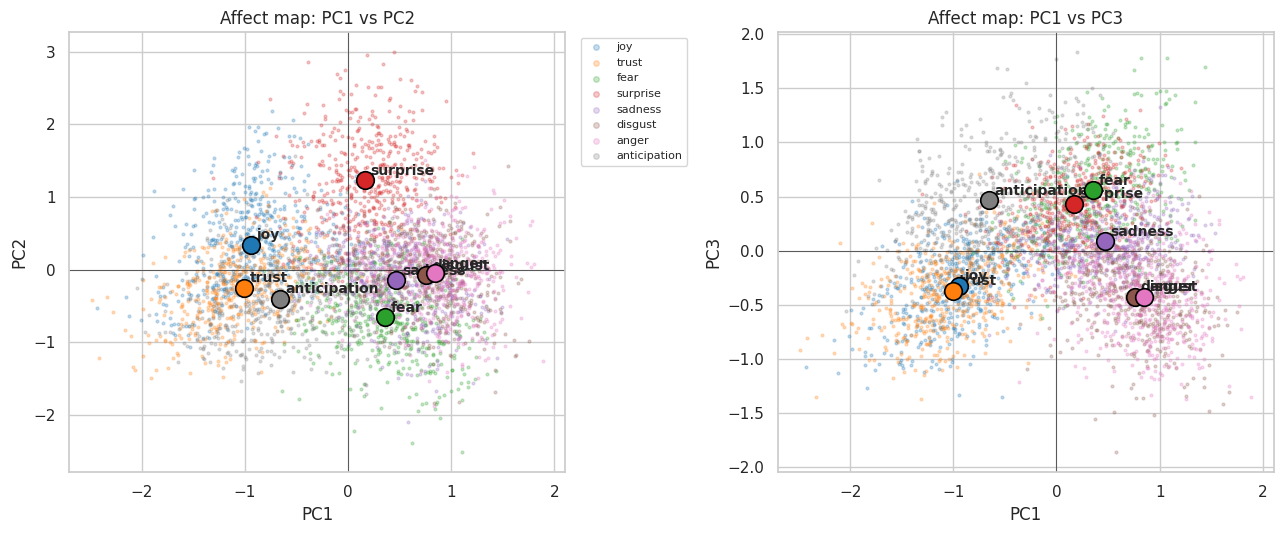

In [17]:
PALETTE = sns.color_palette('tab10', n_colors=len(EMOTIONS))
color_of = dict(zip(EMOTIONS, PALETTE))

def scatter_pc(df: pd.DataFrame, pc_x: str, pc_y: str, ax, sample: int = 4000):
    sub = df.sample(n=min(sample, len(df)), random_state=SEED)
    for emo in EMOTIONS:
        s = sub[sub.emotion == emo]
        ax.scatter(s[pc_x], s[pc_y], s=4, alpha=0.25, color=color_of[emo], label=emo)
    # centroids in PC space
    cent = df.groupby('emotion')[[pc_x, pc_y]].mean().reindex(EMOTIONS)
    for emo, (cx, cy) in cent.iterrows():
        ax.scatter([cx], [cy], s=160, edgecolor='black', facecolor=color_of[emo], linewidth=1.2, zorder=5)
        ax.annotate(emo, (cx, cy), fontsize=10, weight='bold', xytext=(4, 4), textcoords='offset points')
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_xlabel(pc_x); ax.set_ylabel(pc_y)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
scatter_pc(PROJ, 'PC1', 'PC2', axes[0])
scatter_pc(PROJ, 'PC1', 'PC3', axes[1])
axes[0].set_title('Affect map: PC1 vs PC2')
axes[1].set_title('Affect map: PC1 vs PC3')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, markerscale=2)
fig.tight_layout()
fig.savefig(OUT_DIR / 'affect_map_2d.png', dpi=140)
plt.show()

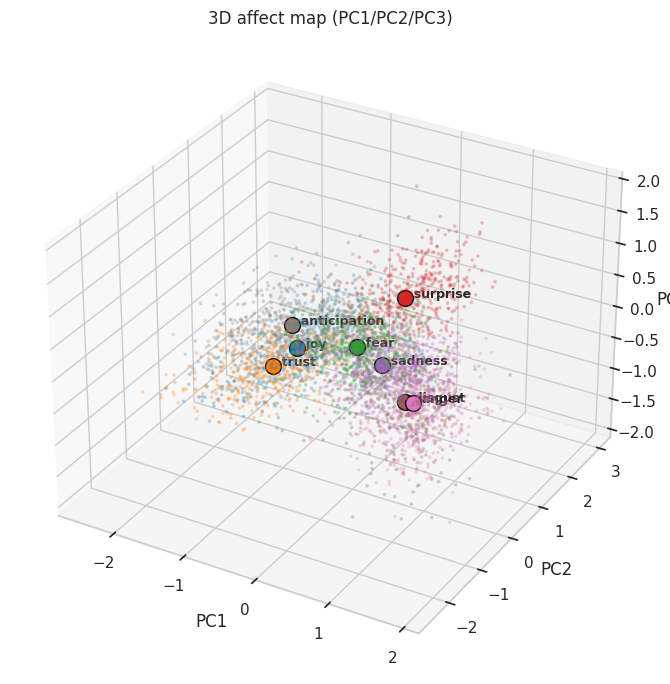

In [18]:
# Optional 3D view (matplotlib).
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
sub = PROJ.sample(n=min(4000, len(PROJ)), random_state=SEED)
for emo in EMOTIONS:
    s = sub[sub.emotion == emo]
    ax.scatter(s['PC1'], s['PC2'], s['PC3'], s=3, alpha=0.2, color=color_of[emo], label=emo)
cent = PROJ.groupby('emotion')[['PC1', 'PC2', 'PC3']].mean().reindex(EMOTIONS)
for emo, (x, y, z) in cent.iterrows():
    ax.scatter([x], [y], [z], s=130, color=color_of[emo], edgecolor='black')
    ax.text(x, y, z, '  ' + emo, fontsize=9, weight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('3D affect map (PC1/PC2/PC3)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'affect_map_3d.png', dpi=140)
plt.show()

## 11. Robustness across layers (10, 16)

We rebuild the PC basis at the auxiliary layers and check that the per-emotion score table
is qualitatively the same. If PC1/PC2 keep the same emotion ordering, the axes are not an
artifact of layer 13.

In [19]:
ROBUST: dict[int, dict] = {LAYER_PRIMARY: pca}
ROBUST_SCORES: dict[int, pd.DataFrame] = {LAYER_PRIMARY: score_df.iloc[:, :K_PCS].copy()}

# Free the primary-layer activations before loading aux layers to keep RAM low.
del X_L, R_L
gc.collect()

for L in LAYERS_AUX:
    X_aux = load_layer_sub(L)
    R_aux = source_center(X_aux)
    C_aux = emotion_centroids(R_aux)
    p_aux = svd_centroids(C_aux, k=K_PCS)
    ROBUST[L] = p_aux
    sd = pd.DataFrame(p_aux['scores'], index=EMOTIONS,
                      columns=[f'PC{i+1}' for i in range(K_PCS)]).round(3)
    ROBUST_SCORES[L] = sd
    print(f'\nLayer {L}: EVR =', np.round(p_aux["evr"][:K_PCS], 3))
    print(sd)
    del X_aux, R_aux, C_aux
    gc.collect()


Layer 10: EVR = [0.404 0.233 0.155 0.095]
                PC1    PC2    PC3    PC4
joy          -0.793  0.360 -0.262 -0.389
trust        -0.795 -0.208 -0.383  0.503
fear          0.316 -0.671  0.401  0.158
surprise      0.032  0.874  0.565  0.237
sadness       0.367 -0.131  0.026 -0.337
disgust       0.667  0.075 -0.371  0.034
anger         0.735  0.114 -0.322  0.021
anticipation -0.529 -0.413  0.344 -0.227

Layer 16: EVR = [0.441 0.259 0.128 0.068]
                PC1    PC2    PC3    PC4
joy          -1.182  0.428 -0.343 -0.490
trust        -1.308 -0.478 -0.432  0.594
fear          0.459 -0.581  0.705  0.280
surprise      0.350  1.616  0.192  0.307
sadness       0.540 -0.223  0.145 -0.229
disgust       0.920 -0.292 -0.448  0.035
anger         0.991 -0.221 -0.504 -0.187
anticipation -0.770 -0.248  0.685 -0.311


In [20]:
# PC alignment across layers: compare the per-emotion score columns by Spearman rank corr.
align_rows = []
for L in LAYERS_AUX:
    for k in range(K_PCS):
        a = ROBUST_SCORES[LAYER_PRIMARY].iloc[:, k].to_numpy()
        # Find the best-matching PC at layer L (allowing sign flip and reordering).
        best = max(
            range(K_PCS),
            key=lambda j: abs(stats.spearmanr(a, ROBUST_SCORES[L].iloc[:, j]).statistic)
        )
        rho = stats.spearmanr(a, ROBUST_SCORES[L].iloc[:, best]).statistic
        align_rows.append({
            'pc_primary': f'PC{k+1}',
            'layer_aux': L,
            'best_aux_pc': f'PC{best+1}',
            'rank_spearman': float(rho),
        })
ALIGN = pd.DataFrame(align_rows)
ALIGN.to_csv(OUT_DIR / 'pc_alignment_across_layers.csv', index=False)
ALIGN.round(2)

,pc_primary,layer_aux,best_aux_pc,rank_spearman
0,PC1,10,PC1,1.00
1,PC2,10,PC2,1.00
2,PC3,10,PC3,0.86
3,PC4,10,PC4,1.00
4,PC1,16,PC1,1.00
5,PC2,16,PC2,0.88
6,PC3,16,PC3,0.98
7,PC4,16,PC4,0.98


## 12. Summary

Bundle the key numerics into a single `summary.json`. Conclusions to write up afterwards:

* **What PC1..PC4 mean**: from §7 (best-matching judge attribute per PC) and §4 (extreme examples).
* **Continuous vs. discrete**: §8 — if judge attributes are linearly recoverable from activations,
  the residual stream is at least as good at encoding *attributes* as it is at encoding *labels*.
* **Global intensity axis**: §9 — whether it aligns with a single PC or is orthogonal.
* **Layer stability**: §11 — whether the axes are layer-13 specific or generic.

In [21]:
summary = {
    'layer_primary': LAYER_PRIMARY,
    'layers_aux': LAYERS_AUX,
    'n_sources_used': int(N_SUB),
    'judge_model': JUDGE_MODEL,
    'judge_sample_size': int(len(JUDGE_DF)),
    'judge_dry_run': bool(DRY_RUN),
    'pca': {
        'singular_values': [float(s) for s in pca['S']],
        'evr': [float(e) for e in pca['evr']],
        'cum_evr': [float(e) for e in np.cumsum(pca['evr'])],
        'emotion_scores': score_df.iloc[:, :K_PCS].to_dict(orient='index'),
    },
    'pc_vs_judge_spearman': CORR.astype(float).to_dict(orient='index'),
    'pc_best_attr': BEST_MATCH.to_dict(orient='records'),
    'judge_probe_from_activation': PROBE.set_index('attr').to_dict(orient='index'),
    'v_int_vs_pc_cosine': cos_int_table.set_index('PC')['cos_with_v_int'].to_dict(),
    'v_int_vs_judge_spearman': {k: (float(v) if v == v else None) for k, v in v_int_corr.items()},
    'layer_alignment': ALIGN.to_dict(orient='records'),
}
with open(OUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('wrote', OUT_DIR / 'summary.json')

wrote /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/affective_subspace/summary.json
